In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.optim.lr_scheduler import StepLR
import os
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 976
hidden_sizes = [128, 256, 512, 1024, 512, 256, 64, 16]
output_size = 1
batch_size = 256
learning_rate = 0.0001
weight_decay = 1e-5
num_epochs = 200
early_stopping_patience = 6
lr_step_size = 10
lr_gamma = 0.5
# dropout_rate = 0.5
model_path = 'D:/Kansas/data/10_counties_10km_matched_shapes/model_training_results/FCNN/All_bands_equal_splits_8_months_weather_dates_minmax_norm_clip_10k/best_model.pth'
results_path = 'D:/Kansas/data/10_counties_10km_matched_shapes/model_training_results/FCNN/All_bands_equal_splits_8_months_weather_dates_minmax_norm_clip_10k_test_predictions.txt'

# Paths to data
data_folder = 'D:/Kansas/data/10_counties_10km_matched_shapes/processed_data/All_bands_minmax_clipping_10k_equal_splits_height_8_months_weather_dates/'

test_inputs_path = os.path.join(data_folder, 'test_inputs.npy')
test_labels_path = os.path.join(data_folder, 'test_labels.npy')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model Definition with Dropout
class FCNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(FCNN, self).__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            # layers.append(nn.Dropout(p=dropout_rate))
            prev_size = h
        layers.append(nn.Linear(prev_size, output_size))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Load data
test_inputs = torch.tensor(np.load(test_inputs_path), dtype=torch.float32).to(device)
test_labels = torch.tensor(np.load(test_labels_path), dtype=torch.float32).to(device).view(-1, 1)
test_labels = (test_labels == 255).float()

# Create DataLoader
test_loader = DataLoader(TensorDataset(test_inputs, test_labels), batch_size=batch_size)

# Test set evaluation
model = FCNN(input_size, hidden_sizes, output_size).to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

test_predictions, test_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = (outputs >= 0.5).float()
        test_predictions.extend(predicted.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

test_f1 = f1_score(test_true, test_predictions)
test_precision = precision_score(test_true, test_predictions)
test_recall = recall_score(test_true, test_predictions)
test_conf_matrix = confusion_matrix(test_true, test_predictions)

# Save test results
with open(results_path, 'w') as f:
    f.write(f'Test F1 Score: {test_f1:.4f}\n')
    f.write(f'Test Precision: {test_precision:.4f}\n')
    f.write(f'Test Recall: {test_recall:.4f}\n')
    f.write(f'Test Confusion Matrix:\n{test_conf_matrix}\n')

print("Results saved.")

C:\Users\udays\AppData\Local\Temp\ipykernel_27204\1127035347.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Results saved.


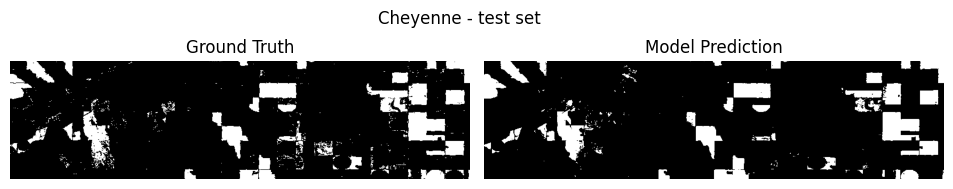

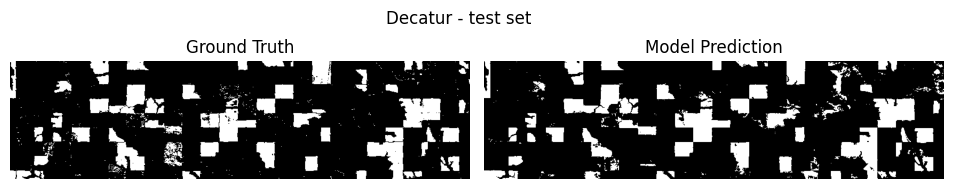

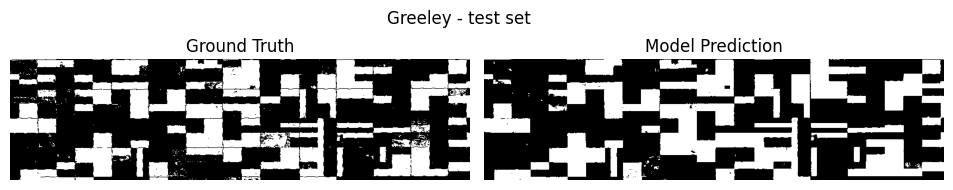

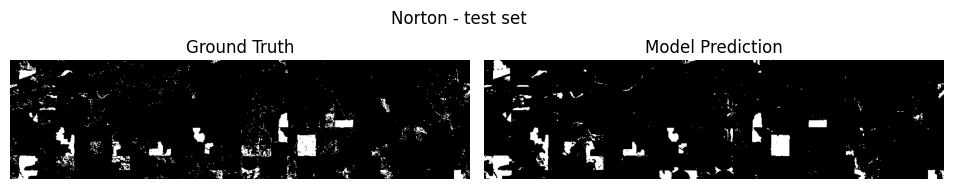

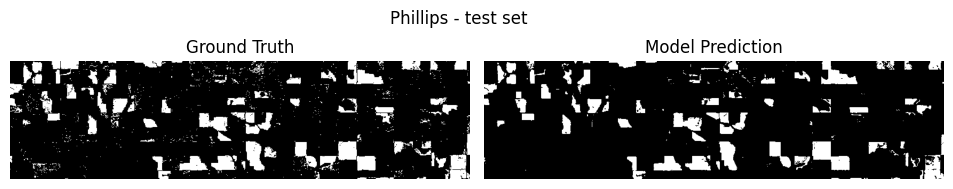

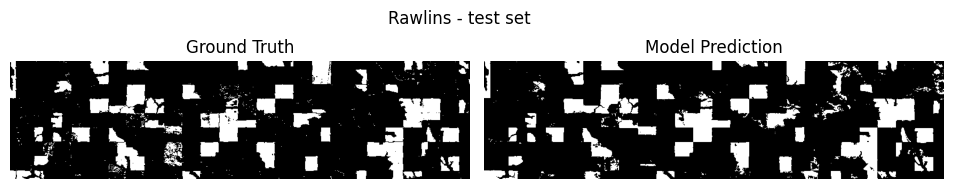

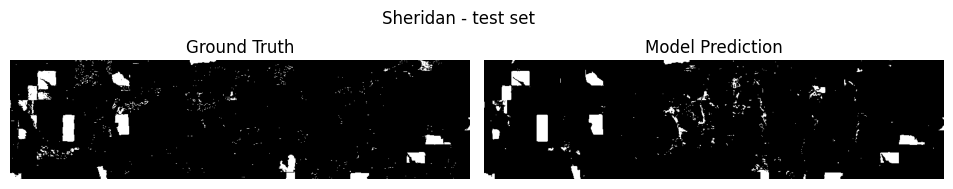

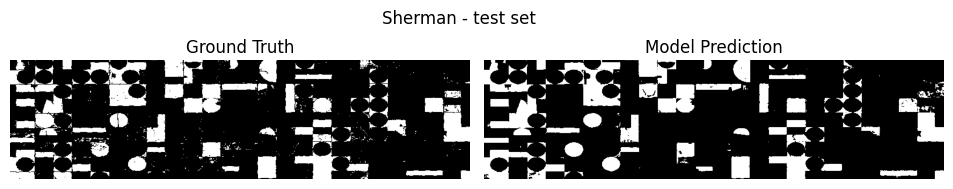

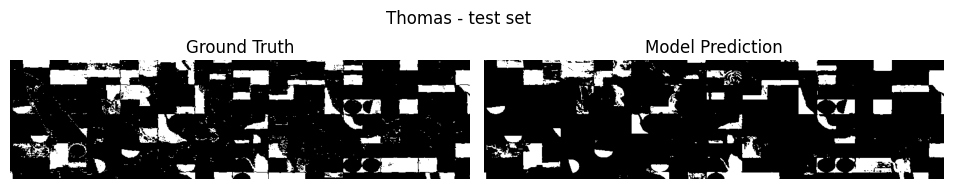

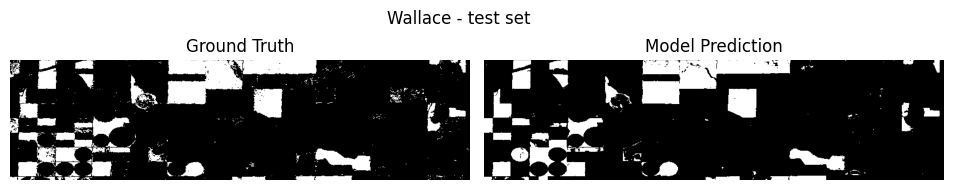

In [4]:
import pickle
with open('../gt_shapes_equal_splits.pkl', "rb") as file:
    shape_dict = pickle.load(file)

results_folder = 'D:/Kansas/data/10_counties_10km_matched_shapes/best_model_results'

def visualize_predictions(predictions, ground_truth, shape_dict, split, results_folder):

    start = 0
    
    for name, shape in shape_dict.items():

        total_H, W = shape

        if split == 'test':
            H = total_H - ((total_H // 3) * 2)
        else:
            H = total_H // 3

        end = start + H * W

        pred_2d = np.array(predictions[start:end], dtype=np.int32).reshape(H, W)
        gt_2d = np.array(ground_truth[start:end], dtype=np.int32).reshape(H, W)
        
        start = end

        # Plot predictions and ground truth side by side
        plt.figure(figsize=(10, 2.3))
        plt.subplot(1, 2, 2)
        plt.imshow(pred_2d, cmap='gray')
        plt.title(f'Model Prediction')
        plt.axis('off')

        plt.subplot(1, 2, 1)
        plt.imshow(gt_2d, cmap='gray')
        plt.title(f'Ground Truth')
        plt.tight_layout()
        plt.axis('off')

        plt.suptitle(f'{name} - {split} set')
        plt.savefig(os.path.join(results_folder, f'{split}_data_{name}_visualization.png'))
        plt.show()
        plt.close()

# Visualize results
visualize_predictions(test_predictions, test_true, shape_dict, 'test', results_folder)